# Malaysian Domestic Tourism — Jadual 10 (2011–2025)
Line charts, trend analysis, statistical preprocessing, and a machine-learning / deep-learning forecast of visitor numbers for 2026–2028.

**Data**: Domestic Tourism Survey (DTS), DOSM — Jadual 10, number of domestic tourists by state of origin and state visited. Unit: **'000 trips**. 16 states × 16 states × 15 years.

**Notebook map**
| Part | Cells | What it does |
|---|---|---|
| 0. Setup & load | 1–2 | Imports, reshape wide → tidy long, integrity check vs published totals |
| 1. Line charts | 3–6 | National, all-state, Penang-focused, indexed / share / YoY / recovery views |
| 2. Trend analysis | 7 | CAGR, COVID drop & recovery, market-share shift, top corridors, correlations |
| 3. Statistics | 8 | Skewness, log1p transform, outliers, Standard/MinMax/Robust scaling |
| 4. ML & DL forecast | 9–13 | Feature engineering, walk-forward backtest, 3 forecast methods + ensemble, optional LSTM, export |

Run the cells top to bottom. Only `pandas`, `numpy`, `matplotlib`, `scikit-learn`, `openpyxl` are required; TensorFlow is optional (Cell 12).

In [ ]:
# =====================================================================
# CELL 1 - Setup
# =====================================================================
import warnings, re, math
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams.update({"figure.figsize": (13, 6), "figure.dpi": 110,
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

FILE   = "Jadual_10_Compiled_2011_2025.xlsx"   # <-- change path if needed
SHEET  = "Jadual 10 Compiled"
HEADER_ROW = 4          # 0-indexed: row 5 in Excel holds the year headers
TOTAL_LABEL = "Malaysia"   # "Malaysia" rows/cols are published totals, not a state
COVID_YEARS = [2020, 2021]
FOCUS  = "Pulau Pinang"    # focus state for the zoom charts (Penang)
FORECAST_YEARS = [2026, 2027, 2028]
RANDOM_STATE = 42
print("Setup done. numpy", np.__version__, "| pandas", pd.__version__)

Setup done. numpy 2.1.3 | pandas 2.2.3


In [ ]:
# =====================================================================
# CELL 2 - Load the workbook and reshape wide -> long (tidy) format
# =====================================================================
raw = pd.read_excel(FILE, sheet_name=SHEET, header=HEADER_ROW)
raw = raw.rename(columns={raw.columns[0]: "origin", raw.columns[1]: "destination"})

def _as_year(c):
    m = re.fullmatch(r"\s*(\d{4})(\.0)?\s*", str(c))
    return int(m.group(1)) if m else None

year_map = {c: _as_year(c) for c in raw.columns if _as_year(c) is not None}
raw["origin"] = raw["origin"].ffill()                 # origin label is merged/blank-filled
raw = raw.dropna(subset=["destination"])
raw = raw.rename(columns=year_map)
YEARS = sorted(year_map.values())

long = raw.melt(id_vars=["origin", "destination"], value_vars=YEARS,
                var_name="year", value_name="visitors")
long["year"] = long["year"].astype(int)
long["visitors"] = pd.to_numeric(long["visitors"], errors="coerce")
long = long.dropna(subset=["visitors"]).reset_index(drop=True)

# flows = state -> state only (drop the published "Malaysia" totals)
flows  = long[(long.origin != TOTAL_LABEL) & (long.destination != TOTAL_LABEL)].copy()
STATES = sorted(flows.destination.unique())

print(f"Years covered      : {YEARS[0]}-{YEARS[-1]}  ({len(YEARS)} years)")
print(f"States             : {len(STATES)}")
print(f"Flow rows (tidy)   : {len(flows):,}  ({len(STATES)}x{len(STATES)} per year)")
print(f"Unit               : '000 tourists")
print("\nSample of tidy data:")
print(flows.head(8).to_string(index=False))

# --- quick integrity check against the published Malaysia x Malaysia total ---
published = long[(long.origin == TOTAL_LABEL) & (long.destination == TOTAL_LABEL)].set_index("year")["visitors"]
computed  = flows.groupby("year")["visitors"].sum()
check = pd.DataFrame({"published_total": published, "sum_of_cells": computed})
check["diff_%"] = (check.sum_of_cells - check.published_total) / check.published_total * 100
print("\nIntegrity check (interior cells vs published national total):")
print(check.round(3).to_string())

Years covered      : 2011-2025  (15 years)
States             : 16
Flow rows (tidy)   : 3,840  (16x16 per year)
Unit               : '000 tourists

Sample of tidy data:
origin     destination  year  visitors
 Johor           Johor  2011  1,686.10
 Johor           Kedah  2011    193.70
 Johor        Kelantan  2011     77.40
 Johor          Melaka  2011    298.60
 Johor Negeri Sembilan  2011    339.30
 Johor          Pahang  2011    162.80
 Johor    Pulau Pinang  2011     53.00
 Johor           Perak  2011    172.90

Integrity check (interior cells vs published national total):
      published_total  sum_of_cells  diff_%
year                                       
2011        45,730.90     45,731.70    0.00
2012        49,383.40     49,382.90   -0.00
2013        54,406.40     54,406.20   -0.00
2014        60,735.90     60,404.40   -0.55
2015        62,730.30     62,729.51   -0.00
2016        66,021.53     66,021.59    0.00
2017        70,523.13     70,523.13    0.00
2018        78,239.12

## Part 1 — Line charts
A single helper draws every chart, giving each state a fixed colour (`tab20`) plus a rotating line style so all 16 lines stay distinguishable. COVID years are shaded on every chart.

In [ ]:
# =====================================================================
# CELL 3 - Reusable line-chart helper (one distinct colour per state)
# =====================================================================
# 16 states need 16 visually separable lines: tab20 colours + 4 line styles.
PALETTE = plt.get_cmap("tab20")(np.linspace(0, 1, 20))
STYLES  = ["-", "--", "-.", ":"]
STATE_STYLE = {s: dict(color=PALETTE[i % 20], linestyle=STYLES[(i // 8) % 4])
               for i, s in enumerate(STATES)}

def line_chart(wide, title, ylabel="Tourists ('000)", highlight=None,
               shade_covid=True, annotate_last=True, ax=None):
    """wide: DataFrame indexed by year, one column per state."""
    if ax is None:
        _, ax = plt.subplots()
    for col in wide.columns:
        st = STATE_STYLE.get(col, dict(color="grey", linestyle="-"))
        lw = 3.0 if (highlight and col == highlight) else 1.7
        al = 1.0 if (highlight is None or col == highlight) else 0.75
        ax.plot(wide.index, wide[col], marker="o", markersize=3.5,
                linewidth=lw, alpha=al, label=col, **st)
        if annotate_last and not np.isnan(wide[col].iloc[-1]):
            ax.annotate(f" {col}", (wide.index[-1], wide[col].iloc[-1]),
                        fontsize=7, va="center", color=st["color"])
    if shade_covid:
        ax.axvspan(2019.5, 2021.5, color="grey", alpha=0.12)
        ax.text(2020.5, ax.get_ylim()[1] * 0.97, "COVID-19", ha="center",
                fontsize=8, color="dimgrey", va="top")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Year"); ax.set_ylabel(ylabel)
    ax.set_xticks(wide.index)
    ax.tick_params(axis="x", rotation=45)
    ax.legend(ncol=4, fontsize=7.5, loc="upper left", framealpha=0.85)
    plt.tight_layout()
    return ax

# Pivot tables used by every chart below
inbound_wide  = flows.pivot_table(index="year", columns="destination", values="visitors", aggfunc="sum")
outbound_wide = flows.pivot_table(index="year", columns="origin",      values="visitors", aggfunc="sum")
national      = flows.groupby("year")["visitors"].sum()
print("Pivot tables ready:", inbound_wide.shape, outbound_wide.shape)

Pivot tables ready: (15, 16) (15, 16)


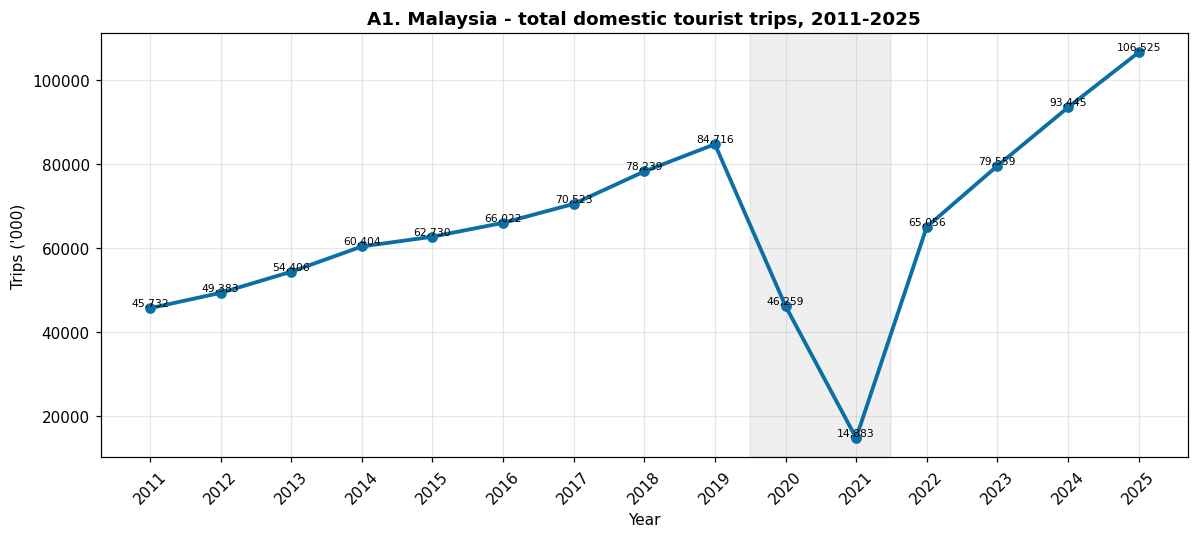

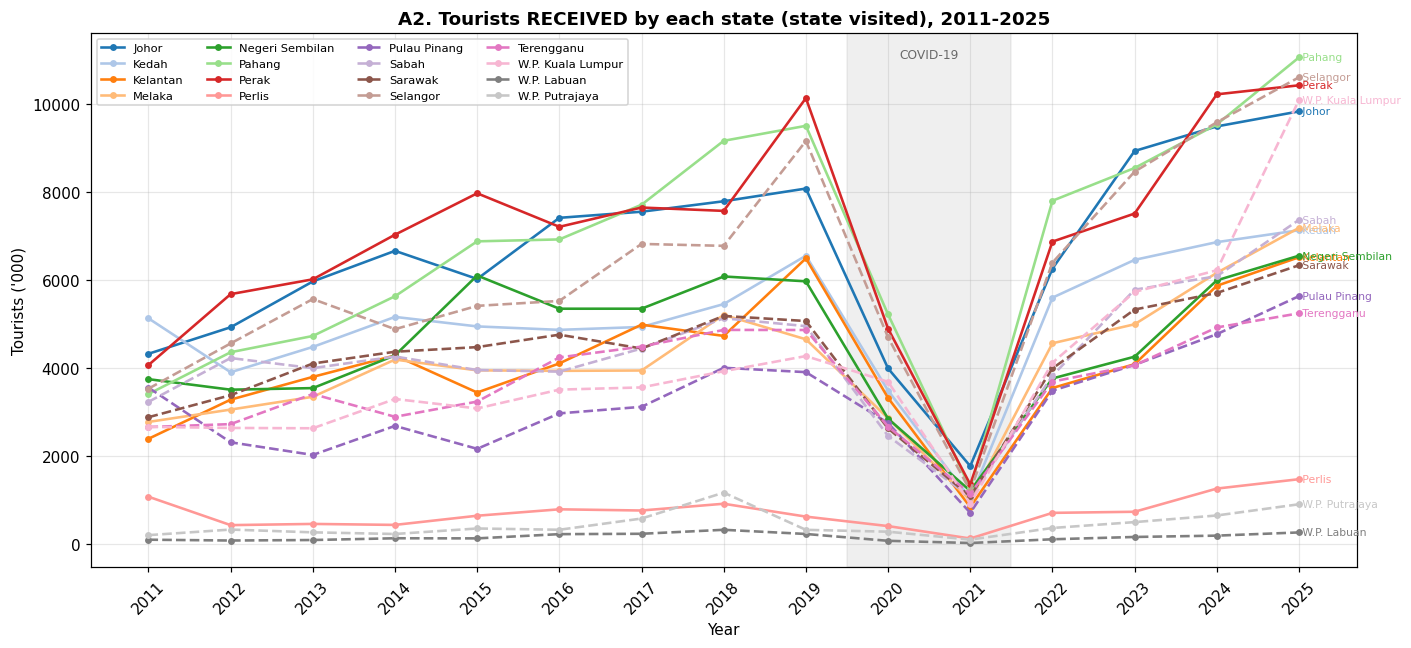

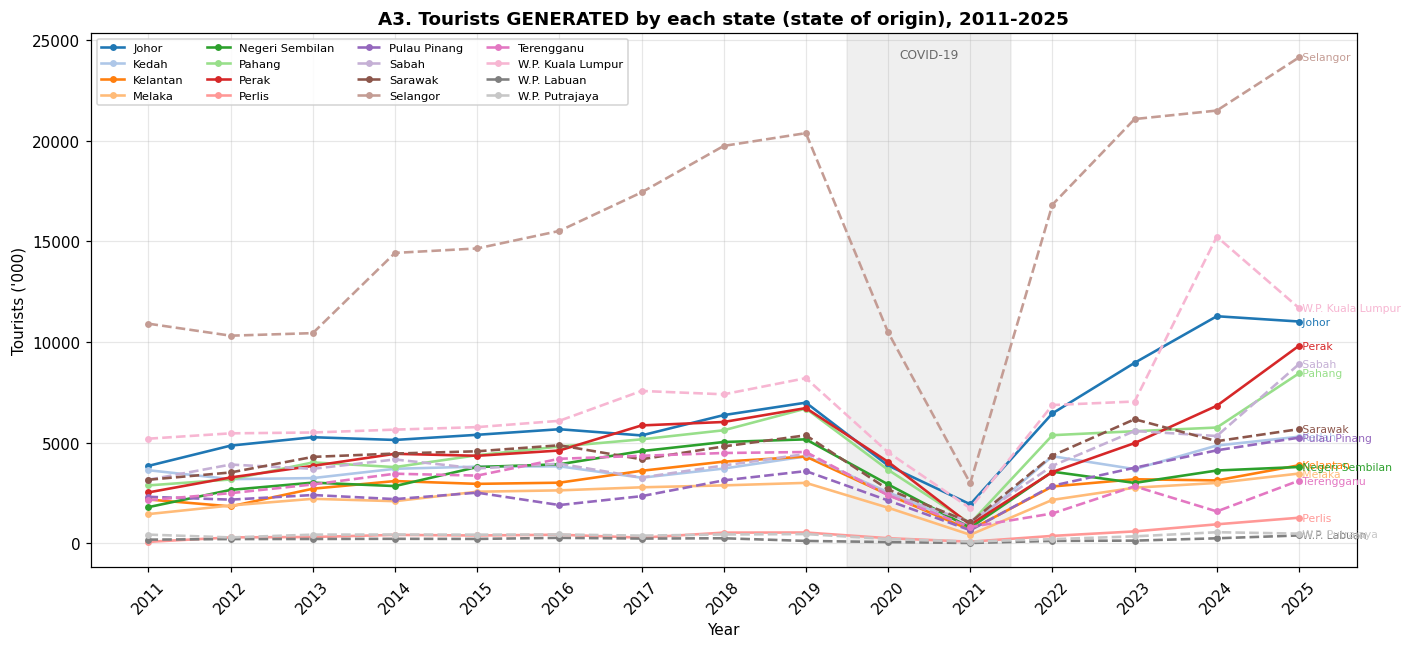

In [ ]:
# =====================================================================
# CELL 4 - CHART SET A: national picture + every state
# =====================================================================
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(national.index, national.values, marker="o", color="#0b6fa4", linewidth=2.5)
ax.axvspan(2019.5, 2021.5, color="grey", alpha=0.12)
for x, v in national.items():
    ax.annotate(f"{v:,.0f}", (x, v), fontsize=7, ha="center", va="bottom")
ax.set_title("A1. Malaysia - total domestic tourist trips, 2011-2025", fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Trips ('000)"); ax.set_xticks(national.index)
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

line_chart(inbound_wide,  "A2. Tourists RECEIVED by each state (state visited), 2011-2025")
plt.show()

line_chart(outbound_wide, "A3. Tourists GENERATED by each state (state of origin), 2011-2025")
plt.show()

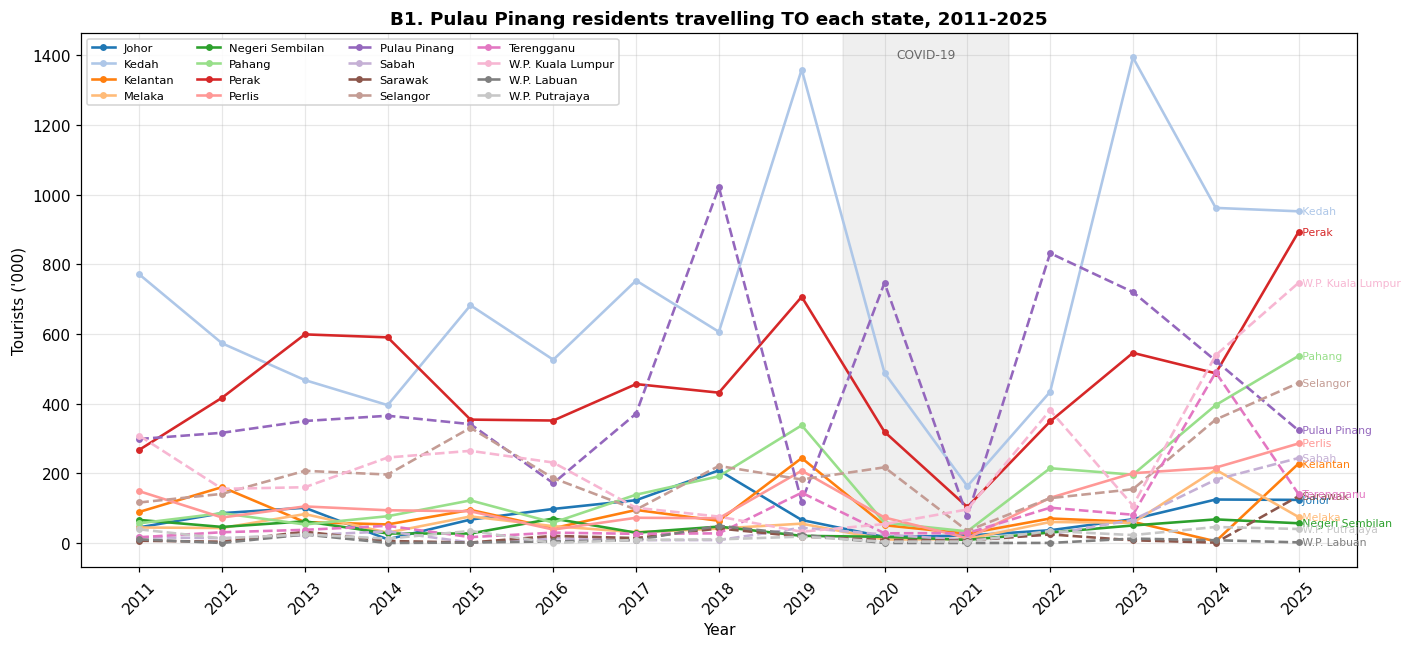

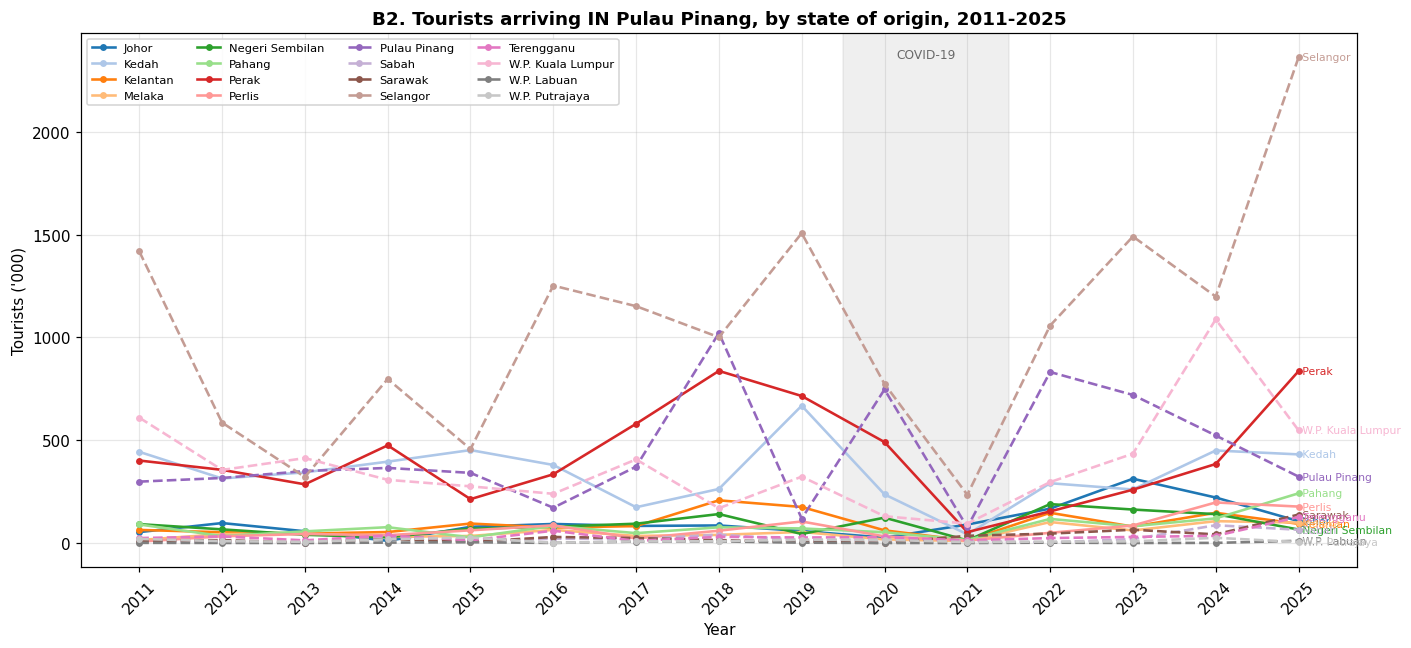

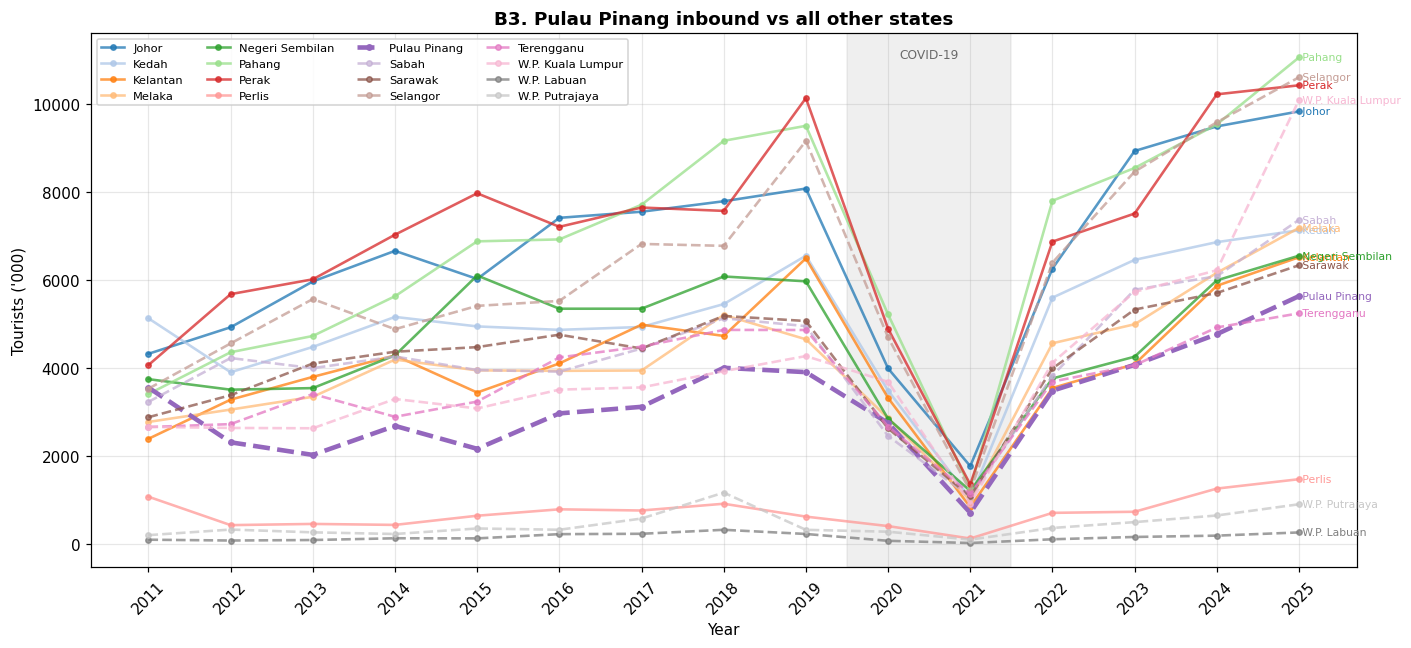

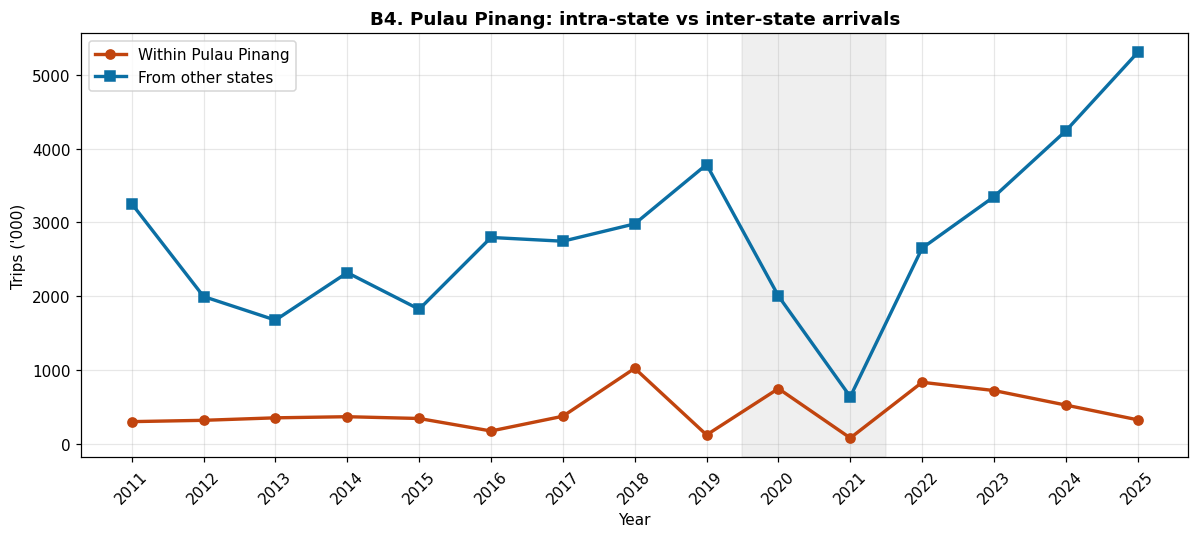

In [ ]:
# =====================================================================
# CELL 5 - CHART SET B: one focus state, both directions
#          (set FOCUS to any state name to reuse this block)
# =====================================================================

# B1. FOCUS -> every other state (where Penang residents travel)
out_focus = (flows[flows.origin == FOCUS]
             .pivot_table(index="year", columns="destination", values="visitors"))
line_chart(out_focus, f"B1. {FOCUS} residents travelling TO each state, 2011-2025")
plt.show()

# B2. every state -> FOCUS (who visits Penang)
in_focus = (flows[flows.destination == FOCUS]
            .pivot_table(index="year", columns="origin", values="visitors"))
line_chart(in_focus, f"B2. Tourists arriving IN {FOCUS}, by state of origin, 2011-2025")
plt.show()

# B3. FOCUS vs all other states on one axis (inbound totals), focus highlighted
line_chart(inbound_wide, f"B3. {FOCUS} inbound vs all other states", highlight=FOCUS)
plt.show()

# B4. same-state (intra-state) travel vs trips from outside, for FOCUS
intra = flows[(flows.origin == FOCUS) & (flows.destination == FOCUS)].set_index("year")["visitors"]
inter = in_focus.drop(columns=[FOCUS]).sum(axis=1)
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(intra.index, intra.values, marker="o", label=f"Within {FOCUS}", color="#c1440e", linewidth=2.2)
ax.plot(inter.index, inter.values, marker="s", label="From other states", color="#0b6fa4", linewidth=2.2)
ax.axvspan(2019.5, 2021.5, color="grey", alpha=0.12)
ax.set_title(f"B4. {FOCUS}: intra-state vs inter-state arrivals", fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Trips ('000)"); ax.set_xticks(intra.index)
ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

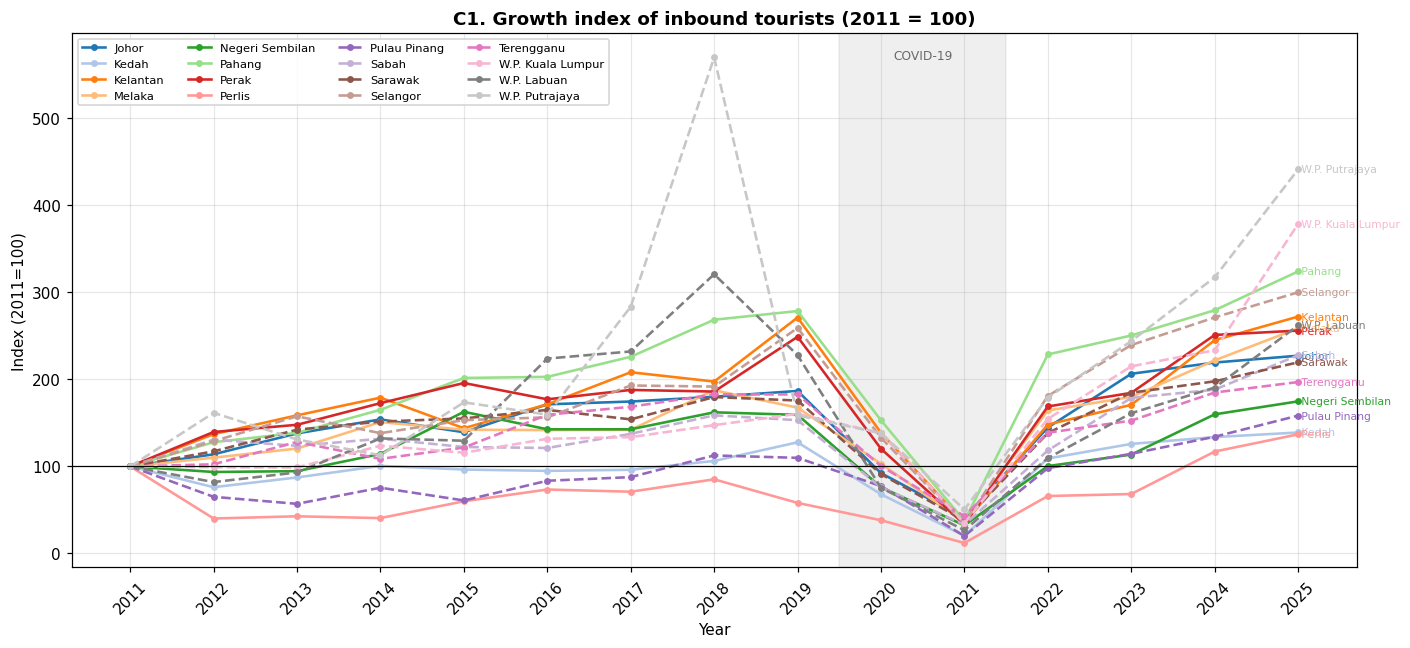

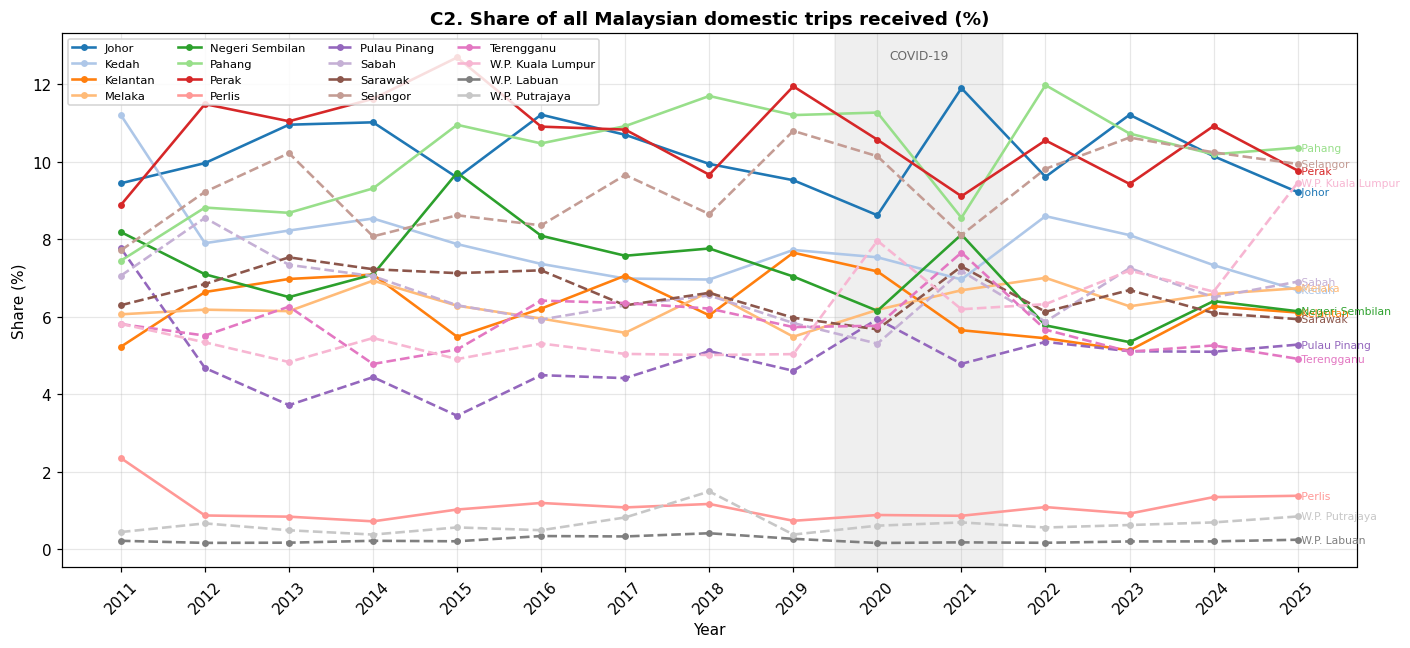

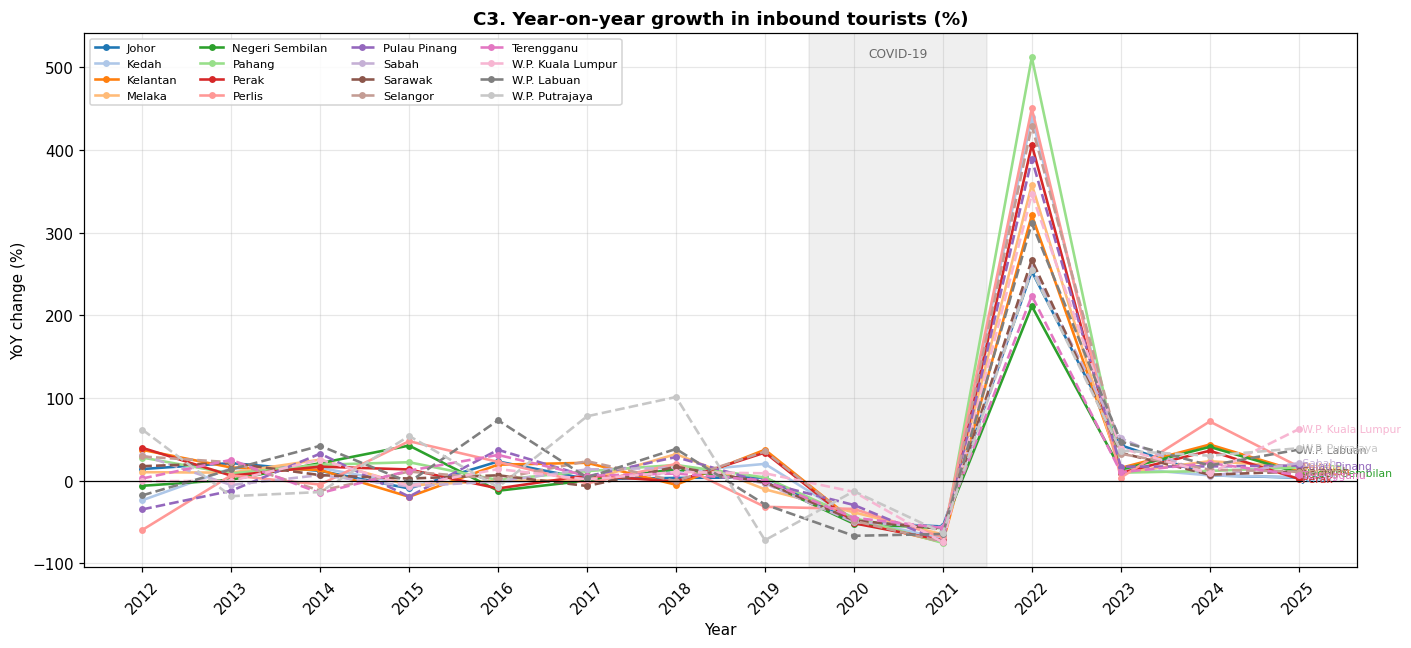

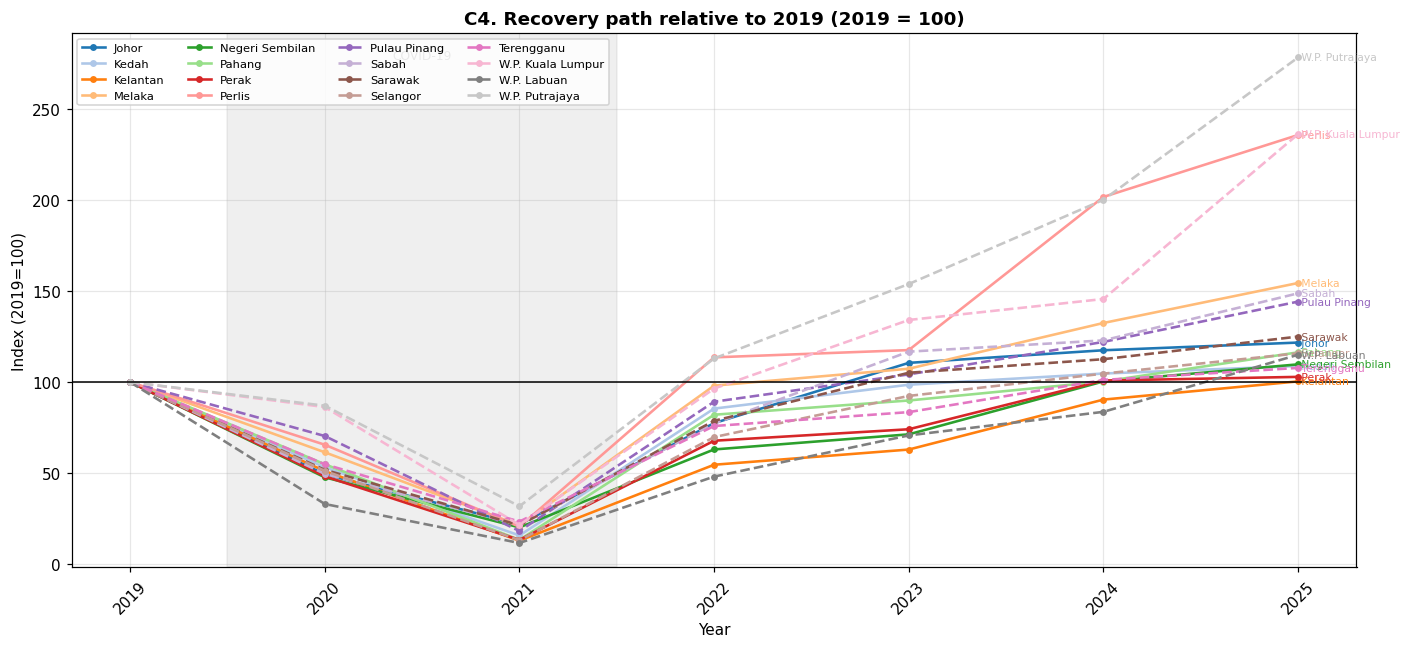

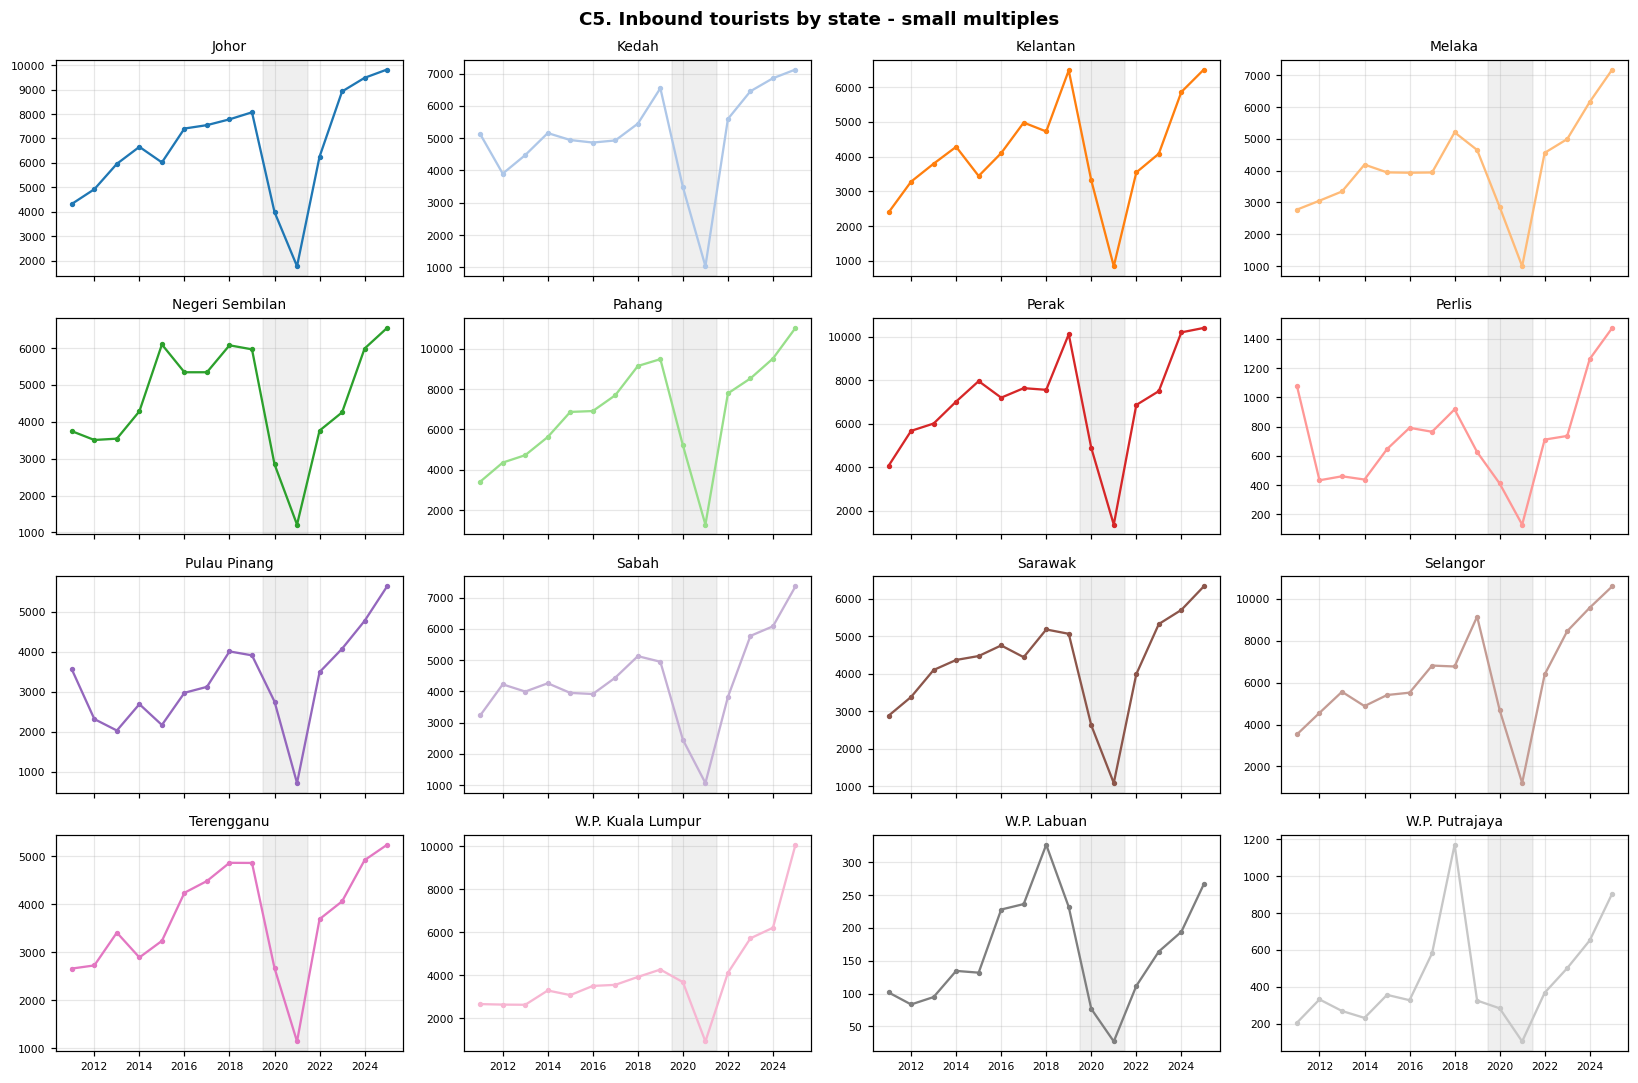

In [ ]:
# =====================================================================
# CELL 6 - CHART SET C: normalised / comparative views
# =====================================================================
# C1. Index chart (2011 = 100) - removes the size effect, compares growth shape
idx = inbound_wide / inbound_wide.iloc[0] * 100
line_chart(idx, "C1. Growth index of inbound tourists (2011 = 100)", ylabel="Index (2011=100)")
plt.axhline(100, color="black", linewidth=0.8)
plt.show()

# C2. Market share of national trips (%)
share = inbound_wide.div(inbound_wide.sum(axis=1), axis=0) * 100
line_chart(share, "C2. Share of all Malaysian domestic trips received (%)", ylabel="Share (%)")
plt.show()

# C3. Year-on-year growth (%)
yoy = inbound_wide.pct_change() * 100
line_chart(yoy.iloc[1:], "C3. Year-on-year growth in inbound tourists (%)", ylabel="YoY change (%)")
plt.axhline(0, color="black", linewidth=0.8)
plt.show()

# C4. Recovery vs 2019 baseline (2019 = 100)
rec = inbound_wide / inbound_wide.loc[2019] * 100
line_chart(rec.loc[2019:], "C4. Recovery path relative to 2019 (2019 = 100)", ylabel="Index (2019=100)")
plt.axhline(100, color="black", linewidth=1.0)
plt.show()

# C5. Small multiples - each state on its own axis (easiest to read per state)
n = len(STATES); ncol = 4; nrow = math.ceil(n / ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.5 * nrow), sharex=True)
for ax, st in zip(axes.ravel(), STATES):
    ax.plot(inbound_wide.index, inbound_wide[st], color=STATE_STYLE[st]["color"], marker="o", markersize=2.5)
    ax.axvspan(2019.5, 2021.5, color="grey", alpha=0.12)
    ax.set_title(st, fontsize=9); ax.tick_params(labelsize=7)
for ax in axes.ravel()[n:]:
    ax.axis("off")
fig.suptitle("C5. Inbound tourists by state - small multiples", fontweight="bold")
plt.tight_layout(); plt.show()

## Part 2 — Finding the trend
Every visual pattern above is converted into a number: growth rates for the pre-COVID era and the recovery era separately (a single 2011–2025 CAGR hides the structural break), the depth of the COVID collapse, the recovery position against 2019, the linear trend slope, and the shift in each state's share of the national market.

In [ ]:
# =====================================================================
# CELL 7 - TREND ANALYSIS (2): quantifying what the charts show
# =====================================================================
def cagr(first, last, periods):
    return np.nan if (first <= 0 or last <= 0 or periods <= 0) else ((last / first) ** (1 / periods) - 1) * 100

rows = []
for st in STATES:
    s = inbound_wide[st]
    slope, intercept = np.polyfit(s.index.values, s.values, 1)
    r = np.corrcoef(s.index.values, s.values)[0, 1]
    rows.append({
        "state": st,
        "2011": s[2011], "2019": s[2019], "2021": s[2021], "2025": s[2025],
        "CAGR_11_19_%": cagr(s[2011], s[2019], 8),
        "CAGR_22_25_%": cagr(s[2022], s[2025], 3),
        "CAGR_11_25_%": cagr(s[2011], s[2025], 14),
        "COVID_drop_%": (s[2021] / s[2019] - 1) * 100,
        "vs_2019_%":    (s[2025] / s[2019] - 1) * 100,
        "trend_slope_per_yr": slope,
        "linearity_r": r,
        "share_2011_%": s[2011] / inbound_wide.loc[2011].sum() * 100,
        "share_2025_%": s[2025] / inbound_wide.loc[2025].sum() * 100,
    })
trend = pd.DataFrame(rows).set_index("state")
trend["share_shift_pp"] = trend["share_2025_%"] - trend["share_2011_%"]

print("=" * 110)
print("TREND TABLE - inbound tourists by state (all figures in '000 unless noted)")
print("=" * 110)
print(trend.sort_values("2025", ascending=False).round(2).to_string())

print("\n--- National trend ---")
print(f"2011 total                : {national[2011]:,.1f}k")
print(f"2019 pre-COVID peak       : {national[2019]:,.1f}k")
print(f"2021 trough               : {national[2021]:,.1f}k  ({national[2021]/national[2019]-1:+.1%} vs 2019)")
print(f"2025 latest               : {national[2025]:,.1f}k  ({national[2025]/national[2019]-1:+.1%} vs 2019)")
print(f"CAGR 2011-2019            : {cagr(national[2011], national[2019], 8):.2f}% per year")
print(f"CAGR 2022-2025 (recovery) : {cagr(national[2022], national[2025], 3):.2f}% per year")
print(f"CAGR 2011-2025 (whole)    : {cagr(national[2011], national[2025], 14):.2f}% per year")

print("\n--- Fastest / slowest structural growth (share shift, percentage points 2011 -> 2025) ---")
ss = trend["share_shift_pp"].sort_values(ascending=False)
print("Gaining share :", ", ".join(f"{k} {v:+.2f}pp" for k, v in ss.head(5).items()))
print("Losing share  :", ", ".join(f"{k} {v:+.2f}pp" for k, v in ss.tail(5).items()))

print("\n--- Year-on-year growth of national total (%) ---")
print((national.pct_change() * 100).round(2).to_string())

print("\n--- Top 15 origin -> destination corridors in 2025 ---")
top = (flows[flows.year == 2025].sort_values("visitors", ascending=False).head(15))
top = top.assign(same_state=lambda d: np.where(d.origin == d.destination, "intra-state", "inter-state"))
print(top.to_string(index=False))

intra_share = (flows[flows.origin == flows.destination].groupby("year")["visitors"].sum() / national * 100)
print("\n--- Intra-state travel as % of all trips ---")
print(intra_share.round(2).to_string())

print("\n--- Correlation of state series with the national total (how in-sync each state is) ---")
print(inbound_wide.corrwith(national).sort_values(ascending=False).round(3).to_string())

TREND TABLE - inbound tourists by state (all figures in '000 unless noted)
                      2011      2019     2021      2025  CAGR_11_19_%  CAGR_22_25_%  CAGR_11_25_%  COVID_drop_%  vs_2019_%  trend_slope_per_yr  linearity_r  share_2011_%  share_2025_%  share_shift_pp
state                                                                                                                                                                                                  
Pahang            3,407.60  9,494.24 1,273.79 11,045.98         13.66         12.33          8.76        -86.58      16.34              335.02         0.56          7.45         10.37            2.92
Selangor          3,529.70  9,149.42 1,207.37 10,595.56         12.64         18.37          8.17        -86.80      15.81              314.82         0.57          7.72          9.95            2.23
Perak             4,065.10 10,122.75 1,356.45 10,413.82         12.08         14.89          6.95        -86.60       2.88   

## Part 3 — Statistics and preprocessing
The flow matrix is extremely right-skewed: a handful of large intra-state cells sit alongside hundreds of tiny inter-state ones. `log1p` fixes the skew and turns multiplicative growth into an additive trend, which is what the models need. Scalers are always fitted on training years only — fitting on the full series would leak future information into the backtest.

--- Descriptive statistics of the flow values ('000) ---
count   3,840.00
mean      254.66
std       535.28
min         0.00
25%        10.40
50%        55.00
75%       241.73
max     5,536.04

Skewness : 4.09   (>1 = heavily right-skewed)
Kurtosis : 21.25
Zeros / near-zeros (<1k trips): 283
Skewness after log1p : -0.13


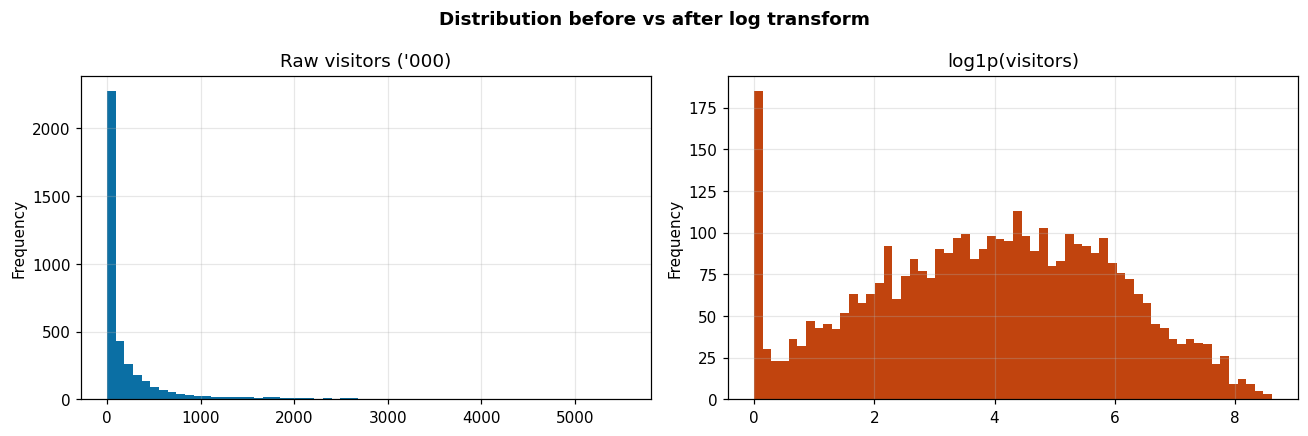


IQR upper fence = 588.7k -> 433 outlier cells (34% of them are intra-state travel)

StandardScaler (z-score): visitors -> mean 0.041, sd 1.057, min -0.46, max 10.47

MinMaxScaler (0-1): visitors -> mean 0.052, sd 0.108, min 0.00, max 1.12

RobustScaler (median/IQR): visitors -> mean 1.042, sd 2.696, min -0.24, max 27.65


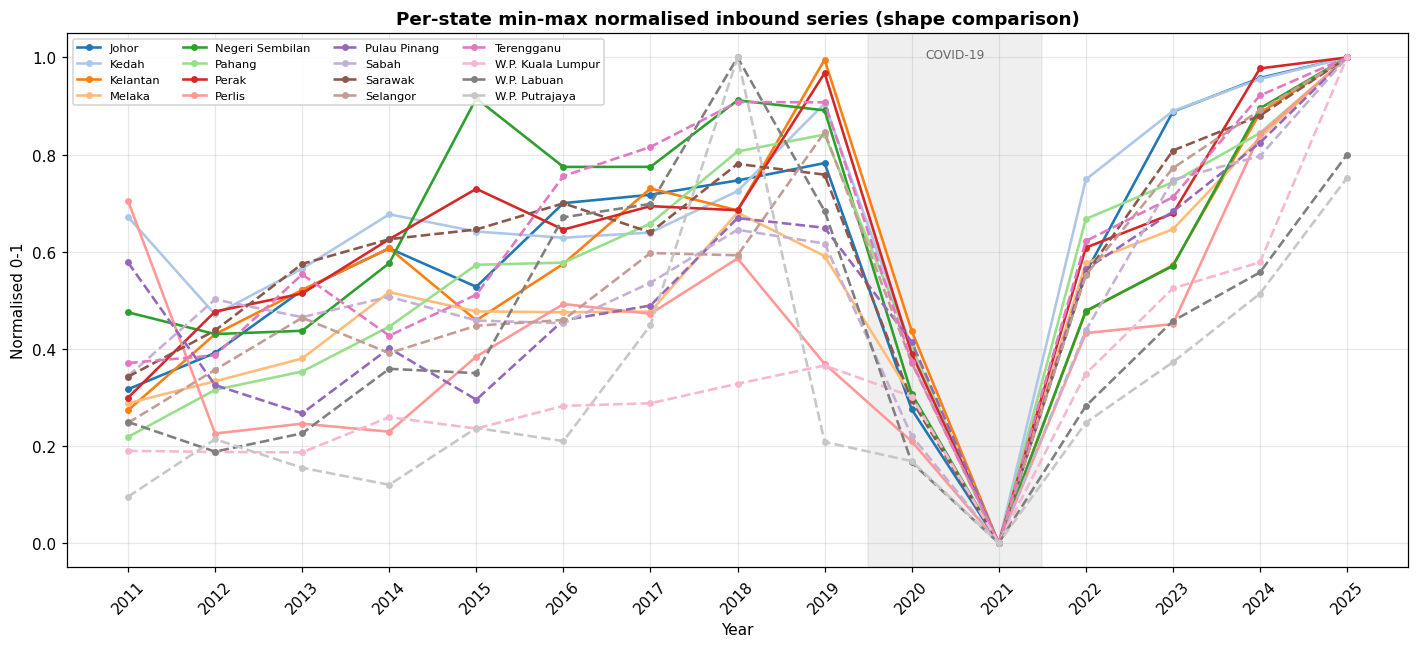


Normalisation choice used downstream: log1p target + StandardScaler on features,
fitted on training years only. MinMax (per series) is used for the LSTM section.


In [ ]:
# =====================================================================
# CELL 8 - STATISTICS / PREPROCESSING (3): distribution, transform, scaling
# =====================================================================
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

print("--- Descriptive statistics of the flow values ('000) ---")
print(flows["visitors"].describe().round(2).to_string())
print(f"\nSkewness : {flows['visitors'].skew():.2f}   (>1 = heavily right-skewed)")
print(f"Kurtosis : {flows['visitors'].kurtosis():.2f}")
print(f"Zeros / near-zeros (<1k trips): {(flows['visitors'] < 1).sum()}")

# The matrix is extremely right-skewed (a few huge intra-state cells, many tiny ones),
# so log1p is applied BEFORE scaling. That is the key statistical step here.
flows["log_visitors"] = np.log1p(flows["visitors"])
print(f"Skewness after log1p : {flows['log_visitors'].skew():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(flows["visitors"], bins=60, color="#0b6fa4"); axes[0].set_title("Raw visitors ('000)")
axes[1].hist(flows["log_visitors"], bins=60, color="#c1440e"); axes[1].set_title("log1p(visitors)")
for a in axes: a.set_ylabel("Frequency")
plt.suptitle("Distribution before vs after log transform", fontweight="bold")
plt.tight_layout(); plt.show()

# Outlier scan (IQR rule) - expect the intra-state cells to dominate
q1, q3 = flows["visitors"].quantile([.25, .75]); iqr = q3 - q1
hi = q3 + 1.5 * iqr
out = flows[flows["visitors"] > hi]
print(f"\nIQR upper fence = {hi:,.1f}k -> {len(out)} outlier cells "
      f"({out.assign(i=out.origin==out.destination)['i'].mean():.0%} of them are intra-state travel)")

# --- Scaling demonstrations (fit on TRAIN years only to avoid look-ahead leakage) ---
train_mask_demo = flows.year <= 2023
demo = flows[["visitors", "log_visitors"]]
for name, scaler in [("StandardScaler (z-score)", StandardScaler()),
                     ("MinMaxScaler (0-1)",       MinMaxScaler()),
                     ("RobustScaler (median/IQR)", RobustScaler())]:
    scaler.fit(demo[train_mask_demo])
    z = scaler.transform(demo)
    print(f"\n{name}: visitors -> mean {z[:,0].mean():.3f}, sd {z[:,0].std():.3f}, "
          f"min {z[:,0].min():.2f}, max {z[:,0].max():.2f}")

# Per-state min-max normalisation, useful for comparing shapes and for the LSTM later
norm_states = (inbound_wide - inbound_wide.min()) / (inbound_wide.max() - inbound_wide.min())
line_chart(norm_states, "Per-state min-max normalised inbound series (shape comparison)",
           ylabel="Normalised 0-1", annotate_last=False)
plt.show()
print("\nNormalisation choice used downstream: log1p target + StandardScaler on features,")
print("fitted on training years only. MinMax (per series) is used for the LSTM section.")

## Part 4 — Machine learning forecast
### 4a. Feature engineering
Each observation is described by its own history (lags 1–3, a 3-year rolling mean, last year's growth), its context (destination and origin totals, the corridor's share of its destination), and time markers (year index, COVID flag, post-COVID flag). Because every feature is built from past values only, the fitted model can be rolled forward recursively into 2026–2028.

In [ ]:
# =====================================================================
# CELL 9 - FEATURE ENGINEERING (4a)
# Panel setup: 16 origins x 16 destinations x 15 years = 3,840 observations.
# Each row is predicted from its own past (lags), so the model can be used
# recursively to roll forward into 2026-2028.
# =====================================================================
KEYS  = ["origin", "destination"]
FEATURES = ["log_lag1", "log_lag2", "log_lag3", "log_roll3", "yoy_ratio",
            "growth1", "t", "covid", "post_covid",
            "log_dest_total_lag1", "log_orig_total_lag1", "dest_share_lag1"]

def make_features(df):
    d = df.sort_values(KEYS + ["year"]).copy()
    g = d.groupby(KEYS)["visitors"]
    d["log_visitors"] = np.log1p(d["visitors"])
    for L in (1, 2, 3):
        d[f"lag{L}"] = g.shift(L)
    d["roll3"] = g.transform(lambda s: s.shift(1).rolling(3).mean())
    for c in ["lag1", "lag2", "lag3", "roll3"]:
        d["log_" + c] = np.log1p(d[c])
    d["yoy_ratio"] = (d.lag1 / d.lag2.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan).fillna(1.0).clip(0, 5)
    d["growth1"]   = d.log_lag1 - d.log_lag2                 # last observed log-growth
    d["t"]          = d.year - YEARS[0]                      # linear time index
    d["covid"]      = d.year.isin(COVID_YEARS).astype(int)
    d["post_covid"] = (d.year >= 2022).astype(int)
    dest_tot = d.groupby(["destination", "year"])["lag1"].transform("sum")
    orig_tot = d.groupby(["origin", "year"])["lag1"].transform("sum")
    d["log_dest_total_lag1"] = np.log1p(dest_tot)            # destination-level context
    d["log_orig_total_lag1"] = np.log1p(orig_tot)            # origin-level context
    d["dest_share_lag1"] = (d.lag1 / dest_tot.replace(0, np.nan)).fillna(0)
    return d

def design_matrix(d, columns=None):
    X = pd.get_dummies(d[FEATURES + KEYS], columns=KEYS, dtype=float)
    if columns is not None:
        X = X.reindex(columns=columns, fill_value=0.0)
    return X

panel = make_features(flows[["origin", "destination", "year", "visitors"]])
model_df = panel.dropna(subset=["log_lag3", "log_roll3", "growth1"]).reset_index(drop=True)
X_all = design_matrix(model_df)
y_all = model_df["log_visitors"].values          # target = log1p(visitors)
MODEL_COLS = list(X_all.columns)
LOG_CAP = np.log1p(flows.visitors.max() * 5)     # safety clip for runaway predictions

print(f"Modelling rows : {len(model_df):,} (years {model_df.year.min()}-{model_df.year.max()};")
print(f"                 first 3 years consumed by lags)")
print(f"Design matrix  : {X_all.shape[0]} x {X_all.shape[1]} features")
print(f"Target         : log1p(visitors), range {y_all.min():.2f} - {y_all.max():.2f}")
print("\nEngineered features:", ", ".join(FEATURES))
print("\nFeature preview:")
print(model_df.loc[model_df.year == 2025, KEYS + FEATURES].head(5).round(3).to_string(index=False))

Modelling rows : 3,072 (years 2014-2025;
                 first 3 years consumed by lags)
Design matrix  : 3072 x 44 features
Target         : log1p(visitors), range 0.00 - 8.62

Engineered features: log_lag1, log_lag2, log_lag3, log_roll3, yoy_ratio, growth1, t, covid, post_covid, log_dest_total_lag1, log_orig_total_lag1, dest_share_lag1

Feature preview:
origin     destination  log_lag1  log_lag2  log_lag3  log_roll3  yoy_ratio  growth1  t  covid  post_covid  log_dest_total_lag1  log_orig_total_lag1  dest_share_lag1
 Johor           Johor      8.22      8.39      7.60       8.12       0.84    -0.18 14      0           1                 9.16                 9.33             0.39
 Johor           Kedah      5.29      5.66      6.45       5.92       0.69    -0.38 14      0           1                 8.83                 9.33             0.03
 Johor        Kelantan      6.05      5.43      6.19       5.94       1.87     0.62 14      0           1                 8.68                 9.3

### 4b. Walk-forward backtest
Annual tourism data must never be shuffled into random train/test splits — that would let the model see the future. Instead, for each of 2023, 2024 and 2025 the model is trained only on strictly earlier years. Three naive benchmarks are included: any model that cannot beat them is not adding value.

In [ ]:
# =====================================================================
# CELL 10 - MODEL TRAINING + ROLLING-ORIGIN BACKTEST (4b)
# Time-series data must never be shuffled: for each test year the model is
# trained only on strictly earlier years (walk-forward validation).
# =====================================================================
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def build_models():
    return {
        "Ridge (linear)": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
        "RandomForest": RandomForestRegressor(n_estimators=500, min_samples_leaf=2,
                                              random_state=RANDOM_STATE, n_jobs=-1),
        "ExtraTrees": ExtraTreesRegressor(n_estimators=500, min_samples_leaf=2,
                                          random_state=RANDOM_STATE, n_jobs=-1),
        "GradientBoosting": GradientBoostingRegressor(n_estimators=400, learning_rate=0.05,
                                                      max_depth=3, random_state=RANDOM_STATE),
        "MLP neural net (256-128-64)": TransformedTargetRegressor(
            regressor=make_pipeline(StandardScaler(),
                                    MLPRegressor(hidden_layer_sizes=(256, 128, 64), activation="relu",
                                                 alpha=1e-3, max_iter=4000, early_stopping=True,
                                                 random_state=RANDOM_STATE)),
            transformer=StandardScaler()),
    }

def score(actual, pred):
    actual, pred = np.asarray(actual, float), np.asarray(pred, float)
    nz = actual > 0
    return dict(MAE=mean_absolute_error(actual, pred),
                RMSE=np.sqrt(mean_squared_error(actual, pred)),
                MedAE=np.median(np.abs(actual - pred)),
                MAPE_nonzero=np.mean(np.abs((actual[nz] - pred[nz]) / actual[nz])) * 100,
                R2=r2_score(actual, pred))

BACKTEST_YEARS = [2023, 2024, 2025]
records, fold_preds = [], []

for test_year in BACKTEST_YEARS:
    tr = model_df.year < test_year
    te = model_df.year == test_year
    Xtr, Xte = X_all[tr], X_all[te]
    ytr, yte = y_all[tr], y_all[te]
    actual = np.expm1(yte)

    for name, mdl in build_models().items():
        mdl.fit(Xtr, ytr)
        pred = np.expm1(np.clip(mdl.predict(Xte), 0, LOG_CAP))
        records.append(dict(model=name, test_year=test_year, **score(actual, pred)))
        fold_preds.append(pd.DataFrame(dict(model=name, year=test_year,
                                            origin=model_df.loc[te, "origin"].values,
                                            destination=model_df.loc[te, "destination"].values,
                                            actual=actual, pred=pred)))

    # ---- benchmarks every forecast must beat ----
    lag1, lag2 = model_df.loc[te, "lag1"].values, model_df.loc[te, "lag2"].values
    bench = {
        "Baseline: naive (last year)": lag1,
        "Baseline: damped drift": lag1 * np.sqrt(np.divide(lag1, lag2, out=np.ones_like(lag1),
                                                           where=lag2 > 0)),
        "Baseline: 3-yr mean": model_df.loc[te, "roll3"].values,
    }
    for name, pred in bench.items():
        pred = np.nan_to_num(pred, nan=0.0)
        records.append(dict(model=name, test_year=test_year, **score(actual, pred)))
        fold_preds.append(pd.DataFrame(dict(model=name, year=test_year,
                                            origin=model_df.loc[te, "origin"].values,
                                            destination=model_df.loc[te, "destination"].values,
                                            actual=actual, pred=pred)))

results = pd.DataFrame(records)
fold_preds = pd.concat(fold_preds, ignore_index=True)

print("=" * 100)
print("WALK-FORWARD BACKTEST - accuracy per test year (flow level, '000 trips)")
print("=" * 100)
print(results.set_index(["model", "test_year"]).round(2).to_string())

summary = results.groupby("model")[["MAE", "RMSE", "MedAE", "MAPE_nonzero", "R2"]].mean().sort_values("RMSE")
print("\n" + "=" * 100)
print("AVERAGE ACROSS THE 3 BACKTEST YEARS (ranked by RMSE - lower is better)")
print("=" * 100)
print(summary.round(2).to_string())

# State-level accuracy matters more than single-cell accuracy: aggregate and re-score
state_rows = []
for name, grp in fold_preds.groupby("model"):
    agg = grp.groupby(["destination", "year"])[["actual", "pred"]].sum()
    state_rows.append(dict(model=name, **score(agg.actual, agg.pred)))
state_scores = pd.DataFrame(state_rows).set_index("model").sort_values("RMSE")
print("\n" + "=" * 100)
print("SAME BACKTEST, SCORED AT STATE LEVEL (predictions summed per destination state)")
print("=" * 100)
print(state_scores.round(2).to_string())

ML_ONLY = [m for m in summary.index if not m.startswith("Baseline")]
BEST_ML   = summary.loc[ML_ONLY, "RMSE"].idxmin()
BEST_ANY  = summary["RMSE"].idxmin()
print(f"\nBest machine-learning model : {BEST_ML}")
print(f"Best overall (incl. baselines): {BEST_ANY}")
if BEST_ANY.startswith("Baseline"):
    print("NOTE: a simple baseline beats the learners at individual-cell level. With only 15\n"
          "      annual observations per series that is a realistic, well-known outcome, and\n"
          "      tree models cannot extrapolate above the range they were trained on. The\n"
          "      forecast cell therefore reports the ML model alongside two statistical\n"
          "      extrapolations and an ensemble of all three.")

WALK-FORWARD BACKTEST - accuracy per test year (flow level, '000 trips)
                                         MAE   RMSE  MedAE  MAPE_nonzero    R2
model                       test_year                                         
Ridge (linear)              2023      275.15 660.19  69.47        323.96  0.07
RandomForest                2023      140.20 342.85  29.08         97.67  0.75
ExtraTrees                  2023      145.09 366.59  27.86        107.91  0.71
GradientBoosting            2023      126.07 324.87  26.41        115.04  0.77
MLP neural net (256-128-64) 2023      107.70 293.12  22.15        139.13  0.82
Baseline: naive (last year) 2023      105.09 270.83  20.27        106.83  0.84
Baseline: damped drift      2023      379.12 902.95  73.72        236.33 -0.75
Baseline: 3-yr mean         2023      152.33 405.91  24.32         75.90  0.65
Ridge (linear)              2024      159.10 358.71  38.53        137.66  0.70
RandomForest                2024      165.11 327.77  56.82 

### 4c. Forecasting 2026–2028
Three methods are run side by side — a recursive ML forecast, a damped-drift extrapolation, and a damped log-linear trend fitted on the 2022–2025 recovery — plus their ensemble. The spread between methods is the honest uncertainty band; tree-based models in particular cannot predict above the range they were trained on, which biases them low on a fast-growing series.

FORECAST OF INBOUND DOMESTIC TOURISTS BY STATE ('000 trips)  -  ML model = ExtraTrees

METHOD 1 - recursive ML
year                   2026      2027      2028
destination                                    
Johor             10,387.50 10,943.90 11,567.30
Kedah              8,568.50  9,454.30 10,246.80
Kelantan           7,762.80  9,168.90  9,934.60
Melaka             8,091.20  9,378.80 10,013.60
Negeri Sembilan    6,635.90  7,768.60  8,939.30
Pahang            11,468.80 12,429.70 13,094.50
Perak             10,493.40 11,031.90 11,434.20
Perlis             1,754.10  2,389.40  2,941.10
Pulau Pinang       6,215.00  6,774.50  7,554.50
Sabah              7,089.80  7,670.50  8,005.10
Sarawak            6,565.50  7,412.40  7,792.60
Selangor          11,392.70 13,137.60 13,651.20
Terengganu         6,699.40  7,128.40  7,609.10
W.P. Kuala Lumpur 10,332.90 11,688.00 12,627.90
W.P. Labuan          294.80    382.50    471.90
W.P. Putrajaya       958.90  1,081.70  1,242.80

METHOD 2 - damped drift


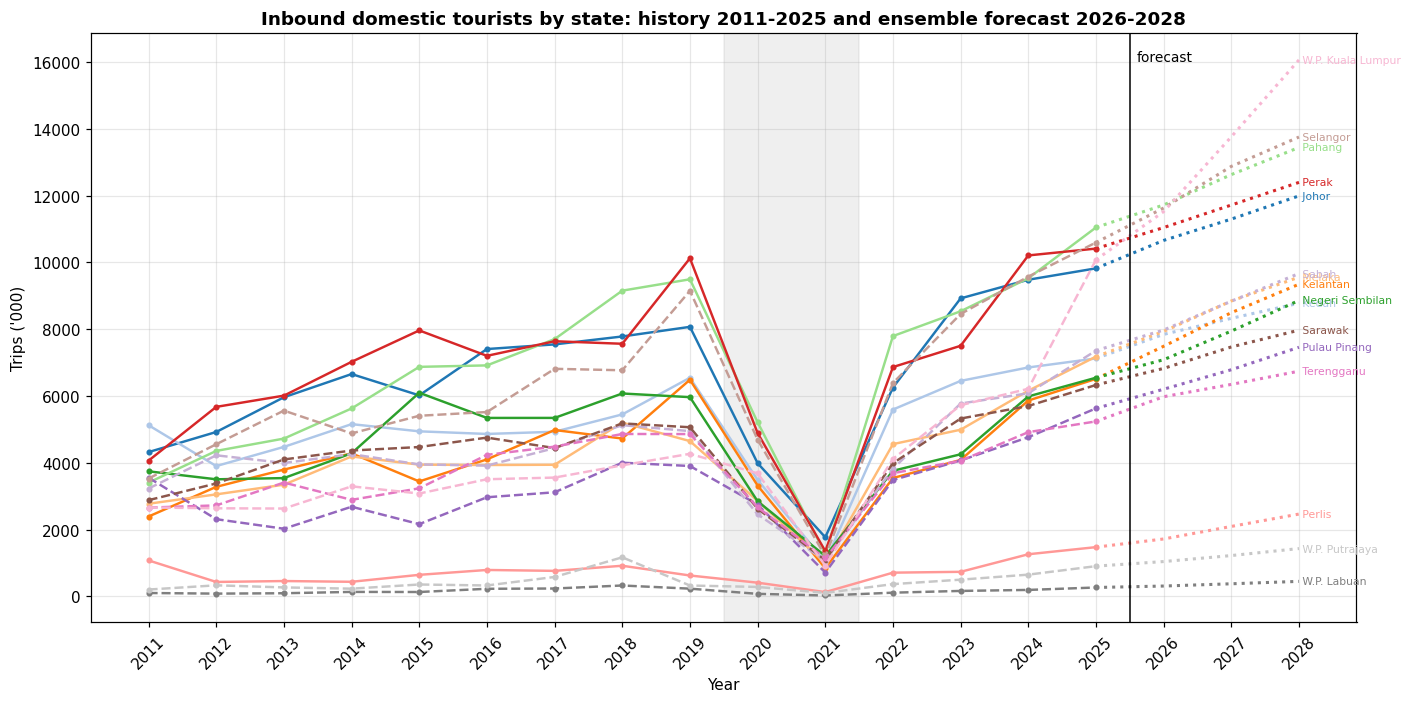

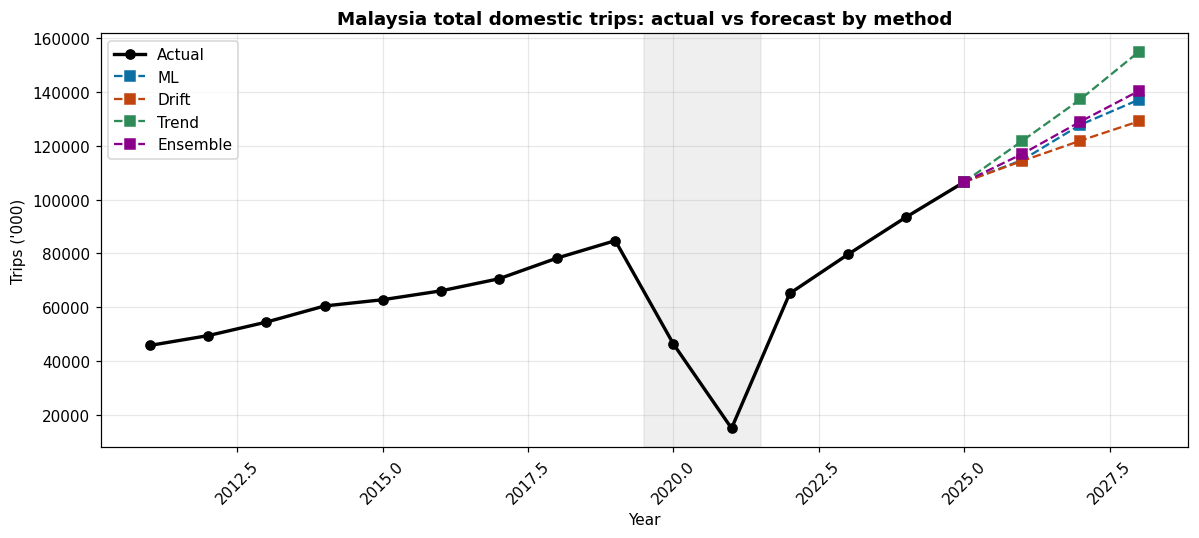

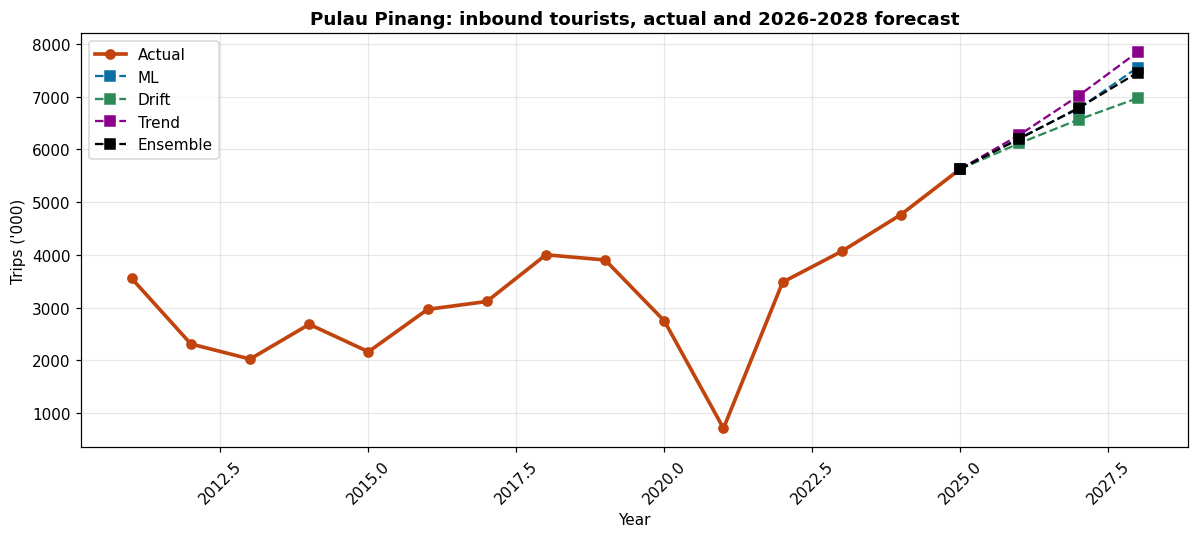

In [ ]:
# =====================================================================
# CELL 11 - FORECAST 2026-2028 (4c)
# Three independent methods + an ensemble, so the spread shows the
# genuine uncertainty rather than one over-confident number.
# =====================================================================

# ---------- Method 1: recursive machine-learning forecast (flow level) ----------
final_model = build_models()[BEST_ML]
final_model.fit(X_all, y_all)                       # refit on every available year

history = flows[["origin", "destination", "year", "visitors"]].copy()
ml_rows = []
for fy in FORECAST_YEARS:
    skeleton = history[history.year == history.year.max()][KEYS].copy()
    skeleton["year"], skeleton["visitors"] = fy, np.nan
    step = make_features(pd.concat([history, skeleton], ignore_index=True))
    step = step[step.year == fy]
    Xf = design_matrix(step, MODEL_COLS)
    pred = np.expm1(np.clip(final_model.predict(Xf), 0, LOG_CAP))
    step_out = step[KEYS + ["year"]].copy(); step_out["visitors"] = pred
    history = pd.concat([history, step_out], ignore_index=True)   # feed prediction back in
    ml_rows.append(step_out)
ml_flow_fc = pd.concat(ml_rows, ignore_index=True)
ml_state_fc = ml_flow_fc.pivot_table(index="year", columns="destination", values="visitors", aggfunc="sum")

# ---------- Method 2: damped drift on each state's inbound series ----------
DAMP = 0.5      # 0 = flat (naive), 1 = full continuation of last growth rate
drift_fc = {}
last = inbound_wide.loc[2025].copy()
rate = (inbound_wide.loc[2025] / inbound_wide.loc[2024]) ** DAMP
for fy in FORECAST_YEARS:
    last = last * rate
    rate = rate ** 0.85                                  # growth fades over the horizon
    drift_fc[fy] = last.copy()
drift_state_fc = pd.DataFrame(drift_fc).T

# ---------- Method 3: log-linear trend fitted on the recovery period ----------
RECOVERY = [2022, 2023, 2024, 2025]
trend_fc = {}
for st in STATES:
    s = np.log(inbound_wide.loc[RECOVERY, st])
    b, a = np.polyfit(np.array(RECOVERY) - 2025, s.values, 1)   # centre on 2025
    level_2025 = math.exp(a)                                    # fitted level at 2025
    b *= 0.7                                                    # damp the steep recovery slope
    trend_fc[st] = {fy: level_2025 * math.exp(b * (fy - 2025)) for fy in FORECAST_YEARS}
trend_state_fc = pd.DataFrame(trend_fc)

# ---------- Ensemble ----------
ens_state_fc = (ml_state_fc + drift_state_fc + trend_state_fc) / 3

print("=" * 100)
print(f"FORECAST OF INBOUND DOMESTIC TOURISTS BY STATE ('000 trips)  -  ML model = {BEST_ML}")
print("=" * 100)
for label, tbl in [("METHOD 1 - recursive ML", ml_state_fc),
                   ("METHOD 2 - damped drift", drift_state_fc),
                   ("METHOD 3 - log-linear recovery trend", trend_state_fc),
                   ("ENSEMBLE (mean of the three)", ens_state_fc)]:
    print(f"\n{label}")
    print(tbl.T.round(1).to_string())

print("\n" + "=" * 100)
print("NATIONAL TOTAL - history and forecast ('000 trips)")
print("=" * 100)
nat_fc = pd.DataFrame({"ML": ml_state_fc.sum(axis=1), "Drift": drift_state_fc.sum(axis=1),
                       "Trend": trend_state_fc.sum(axis=1), "Ensemble": ens_state_fc.sum(axis=1)})
print(pd.concat([pd.DataFrame({"Actual": national}), nat_fc], axis=1).round(1).to_string())
print("\nImplied national growth on the ensemble:")
full = pd.concat([national, ens_state_fc.sum(axis=1)])
print((full.pct_change() * 100).loc[2023:].round(2).to_string())

# ---------- Per-state detail table ----------
detail = pd.DataFrame({
    "2025_actual": inbound_wide.loc[2025],
    "2026_ML": ml_state_fc.loc[2026], "2026_drift": drift_state_fc.loc[2026],
    "2026_trend": trend_state_fc.loc[2026], "2026_ensemble": ens_state_fc.loc[2026],
    "2028_ensemble": ens_state_fc.loc[2028],
})
detail["growth_25_28_%"] = (detail["2028_ensemble"] / detail["2025_actual"] - 1) * 100
print("\nPer-state summary (sorted by 2028 ensemble forecast):")
print(detail.sort_values("2028_ensemble", ascending=False).round(1).to_string())

# ---------- Chart: history + forecast ----------
fig, ax = plt.subplots(figsize=(13, 6.5))
for st in STATES:
    stl = STATE_STYLE[st]
    ax.plot(inbound_wide.index, inbound_wide[st], marker="o", markersize=3, linewidth=1.6, **stl)
    bridge = pd.concat([inbound_wide.loc[[2025], st], ens_state_fc[st]])
    ax.plot(bridge.index, bridge.values, linestyle=":", linewidth=2.0, color=stl["color"])
    ax.annotate(f" {st}", (bridge.index[-1], bridge.iloc[-1]), fontsize=7, color=stl["color"], va="center")
ax.axvspan(2019.5, 2021.5, color="grey", alpha=0.12)
ax.axvline(2025.5, color="black", linewidth=1.0)
ax.text(2025.6, ax.get_ylim()[1] * 0.95, "forecast", fontsize=9)
ax.set_title("Inbound domestic tourists by state: history 2011-2025 and ensemble forecast 2026-2028",
             fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Trips ('000)")
ax.set_xticks(list(inbound_wide.index) + FORECAST_YEARS); plt.xticks(rotation=45)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(national.index, national.values, marker="o", color="black", label="Actual", linewidth=2.2)
for col, c in zip(["ML", "Drift", "Trend", "Ensemble"], ["#0b6fa4", "#c1440e", "#2e8b57", "#8b008b"]):
    br = pd.concat([pd.Series({2025: national[2025]}), nat_fc[col]])
    ax.plot(br.index, br.values, marker="s", linestyle="--", color=c, label=col)
ax.axvspan(2019.5, 2021.5, color="grey", alpha=0.12)
ax.set_title("Malaysia total domestic trips: actual vs forecast by method", fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Trips ('000)"); ax.legend()
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# ---------- Focus state zoom ----------
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(inbound_wide.index, inbound_wide[FOCUS], marker="o", color="#c1440e", linewidth=2.4, label="Actual")
for col, tbl, c in [("ML", ml_state_fc, "#0b6fa4"), ("Drift", drift_state_fc, "#2e8b57"),
                    ("Trend", trend_state_fc, "#8b008b"), ("Ensemble", ens_state_fc, "black")]:
    br = pd.concat([pd.Series({2025: inbound_wide.loc[2025, FOCUS]}), tbl[FOCUS]])
    ax.plot(br.index, br.values, linestyle="--", marker="s", color=c, label=col)
ax.set_title(f"{FOCUS}: inbound tourists, actual and 2026-2028 forecast", fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Trips ('000)"); ax.legend()
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

### 4d. Optional: LSTM (deep learning)
The same problem posed as a sequence task. With 15 annual points per state this is demonstration-scale, so read it as a working pipeline rather than a superior model.

LSTM training windows: (144, 4, 1), test windows: (32, 4, 1)
Final training loss 0.00546 | val loss 0.08528

LSTM backtest 2024-2025 (state level, '000 trips):
          MAE     RMSE    MedAE  MAPE_nonzero   R2
LSTM 1,140.91 1,402.06 1,005.90         19.77 0.81
Compare against the state-level table printed in Cell 10.


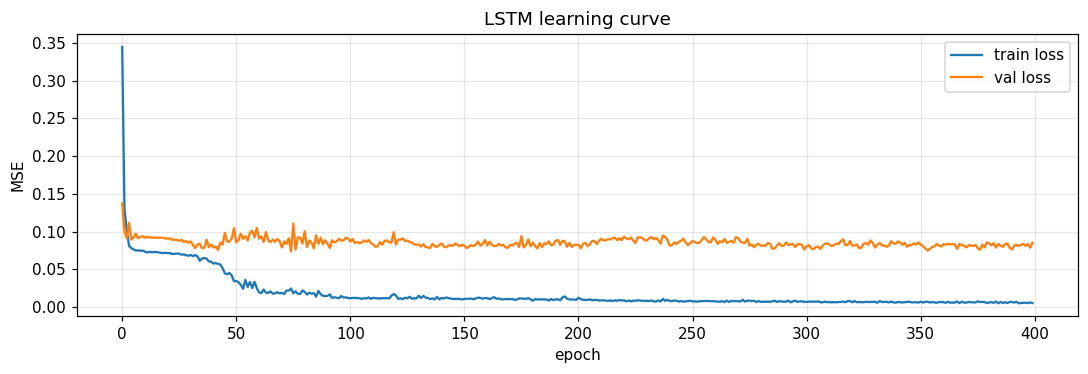


LSTM forecast by state ('000 trips):
                      2026     2027     2028
Johor             8,618.80 5,129.40 8,026.70
Kedah             2,530.30   997.00 3,593.00
Kelantan          5,341.30 4,051.00 6,736.50
Melaka            3,726.10   960.90 5,381.50
Negeri Sembilan   5,884.80 5,445.90 6,828.30
Pahang            3,525.60 1,303.50 5,809.00
Perak             4,909.90 1,343.80 7,346.10
Perlis            1,076.80   311.90   586.10
Pulau Pinang      2,911.70   729.70 4,133.20
Sabah             7,789.90 2,460.70 1,082.50
Sarawak           4,957.30 3,030.40 4,148.50
Selangor          6,113.40 1,923.50 7,588.70
Terengganu        3,338.10 1,163.90 4,235.60
W.P. Kuala Lumpur 8,024.80 7,080.50 6,238.80
W.P. Labuan         302.90   227.90   145.60
W.P. Putrajaya      848.80   910.10   736.50

LSTM national total: {2026: 69900.5, 2027: 37070.0, 2028: 72616.6}


In [ ]:
# =====================================================================
# CELL 12 - OPTIONAL DEEP LEARNING: LSTM on the per-state sequences
# Runs only if TensorFlow is installed ( pip install tensorflow ).
# 16 states x 15 years is a very small sample for an LSTM, so treat this
# as a demonstration of the pipeline, not as the best available model.
# =====================================================================
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
    HAS_TF = True
except Exception as e:
    HAS_TF = False
    print("TensorFlow not available -> skipping the LSTM section.")
    print("Install with:  pip install tensorflow")
    print(f"(import error: {e})")

if HAS_TF:
    tf.random.set_seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)
    SEQ_LEN = 4

    series = np.log1p(inbound_wide)                      # log-scale each state's series
    smin, smax = series.min(), series.max()
    scaled = (series - smin) / (smax - smin)             # per-state min-max normalisation

    def windows(df, year_max):
        Xs, ys, meta = [], [], []
        for st in df.columns:
            v = df[st].values; yr = df.index.values
            for i in range(SEQ_LEN, len(v)):
                if yr[i] > year_max:
                    continue
                Xs.append(v[i - SEQ_LEN:i]); ys.append(v[i]); meta.append((st, yr[i]))
        return np.array(Xs)[..., None], np.array(ys), meta

    Xtr, ytr, _ = windows(scaled, 2023)
    Xte, yte, meta_te = windows(scaled.loc[:2025], 2025)
    keep = np.array([m[1] > 2023 for m in meta_te])
    Xte, yte, meta_te = Xte[keep], yte[keep], [m for m, k in zip(meta_te, keep) if k]
    print(f"LSTM training windows: {Xtr.shape}, test windows: {Xte.shape}")

    def unscale(vals, states):
        out = []
        for v, st in zip(vals, states):
            out.append(np.expm1(v * (smax[st] - smin[st]) + smin[st]))
        return np.array(out)

    lstm = Sequential([Input(shape=(SEQ_LEN, 1)),
                       LSTM(64, return_sequences=True), Dropout(0.1),
                       LSTM(32), Dense(16, activation="relu"), Dense(1)])
    lstm.compile(optimizer=tf.keras.optimizers.Adam(0.005), loss="mse", metrics=["mae"])
    hist = lstm.fit(Xtr, ytr, epochs=400, batch_size=16, verbose=0, validation_split=0.15)
    print(f"Final training loss {hist.history['loss'][-1]:.5f} | val loss {hist.history['val_loss'][-1]:.5f}")

    states_te = [m[0] for m in meta_te]
    pred_te = unscale(lstm.predict(Xte, verbose=0).ravel(), states_te)
    act_te  = unscale(yte, states_te)
    print("\nLSTM backtest 2024-2025 (state level, '000 trips):")
    print(pd.DataFrame(score(act_te, pred_te), index=["LSTM"]).round(2).to_string())
    print("Compare against the state-level table printed in Cell 10.")

    plt.figure(figsize=(10, 3.5))
    plt.plot(hist.history["loss"], label="train loss")
    plt.plot(hist.history["val_loss"], label="val loss")
    plt.title("LSTM learning curve"); plt.xlabel("epoch"); plt.ylabel("MSE"); plt.legend()
    plt.tight_layout(); plt.show()

    # recursive LSTM forecast, state by state
    lstm_fc = {}
    for st in STATES:
        seq = list(scaled[st].values)
        preds = []
        for _ in FORECAST_YEARS:
            nxt = float(lstm.predict(np.array(seq[-SEQ_LEN:]).reshape(1, SEQ_LEN, 1), verbose=0).ravel()[0])
            seq.append(nxt); preds.append(nxt)
        lstm_fc[st] = np.expm1(np.array(preds) * (smax[st] - smin[st]) + smin[st])
    lstm_state_fc = pd.DataFrame(lstm_fc, index=FORECAST_YEARS)
    print("\nLSTM forecast by state ('000 trips):")
    print(lstm_state_fc.T.round(1).to_string())
    print("\nLSTM national total:", lstm_state_fc.sum(axis=1).round(1).to_dict())

## Export and summary

In [ ]:
# =====================================================================
# CELL 13 - FINAL SUMMARY + EXPORT
# =====================================================================
OUT = "domestic_tourism_forecast_2026_2028.xlsx"
with pd.ExcelWriter(OUT, engine="openpyxl") as xl:
    flows.to_excel(xl, sheet_name="tidy_flows", index=False)
    inbound_wide.to_excel(xl, sheet_name="inbound_by_state")
    outbound_wide.to_excel(xl, sheet_name="outbound_by_state")
    trend.to_excel(xl, sheet_name="trend_metrics")
    results.to_excel(xl, sheet_name="backtest_by_year", index=False)
    summary.to_excel(xl, sheet_name="backtest_summary")
    state_scores.to_excel(xl, sheet_name="backtest_state_level")
    ml_state_fc.to_excel(xl, sheet_name="fc_ml")
    drift_state_fc.to_excel(xl, sheet_name="fc_drift")
    trend_state_fc.to_excel(xl, sheet_name="fc_trend")
    ens_state_fc.to_excel(xl, sheet_name="fc_ensemble")
    ml_flow_fc.to_excel(xl, sheet_name="fc_ml_flow_level", index=False)
print(f"Workbook written: {OUT}")

print("\n" + "=" * 100)
print("SUMMARY OF EVERYTHING PRODUCED")
print("=" * 100)
print(f"Data              : {len(flows):,} state-to-state flow observations, {YEARS[0]}-{YEARS[-1]}, unit '000 trips")
print(f"Charts            : national trend, inbound/outbound per state, {FOCUS} in/out, index,")
print( "                    market share, YoY growth, recovery vs 2019, small multiples, forecast fan")
print(f"National 2025     : {national[2025]:,.1f}k trips ({national[2025]/national[2019]-1:+.1%} vs 2019 peak)")
print(f"Fastest growth    : {trend['CAGR_11_25_%'].idxmax()} ({trend['CAGR_11_25_%'].max():.1f}% CAGR 2011-2025)")
print(f"Slowest growth    : {trend['CAGR_11_25_%'].idxmin()} ({trend['CAGR_11_25_%'].min():.1f}% CAGR 2011-2025)")
print(f"{FOCUS:<18}: {inbound_wide.loc[2025, FOCUS]:,.1f}k in 2025, "
      f"{trend.loc[FOCUS,'CAGR_11_25_%']:.1f}% CAGR, share {trend.loc[FOCUS,'share_2025_%']:.1f}% of national")
print(f"Best ML model     : {BEST_ML} (RMSE {summary.loc[BEST_ML,'RMSE']:.1f}k at flow level)")
print(f"Best overall      : {BEST_ANY}")
print(f"Ensemble forecast : 2026 {ens_state_fc.sum(axis=1)[2026]:,.0f}k | "
      f"2027 {ens_state_fc.sum(axis=1)[2027]:,.0f}k | 2028 {ens_state_fc.sum(axis=1)[2028]:,.0f}k")
print("\nCaveats: 15 annual observations per series is a small sample; 2020-2021 are structural")
print("breaks, not noise; and DTS_2014 interior cells under-reconcile by ~0.55%. Treat the")
print("forecasts as a trend range, not a precise number.")

Workbook written: domestic_tourism_forecast_2026_2028.xlsx

SUMMARY OF EVERYTHING PRODUCED
Data              : 3,840 state-to-state flow observations, 2011-2025, unit '000 trips
Charts            : national trend, inbound/outbound per state, Pulau Pinang in/out, index,
                    market share, YoY growth, recovery vs 2019, small multiples, forecast fan
National 2025     : 106,525.3k trips (+25.7% vs 2019 peak)
Fastest growth    : W.P. Putrajaya (11.2% CAGR 2011-2025)
Slowest growth    : Perlis (2.3% CAGR 2011-2025)
Pulau Pinang      : 5,629.5k in 2025, 3.3% CAGR, share 5.3% of national
Best ML model     : ExtraTrees (RMSE 308.2k at flow level)
Best overall      : Baseline: naive (last year)
Ensemble forecast : 2026 116,983k | 2027 129,024k | 2028 140,377k

Caveats: 15 annual observations per series is a small sample; 2020-2021 are structural
breaks, not noise; and DTS_2014 interior cells under-reconcile by ~0.55%. Treat the
forecasts as a trend range, not a precise number.
